In [1]:
# Install if needed
!pip install seaborn --quiet

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set_palette("viridis")


# New Section

In [6]:
import pandas as pd


In [9]:
df = pd.read_csv("/content/final.csv", encoding="cp1252")

/tmp/ipython-input-311/2406214752.py:1: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/final.csv", encoding="cp1252")


In [10]:
df['DATETIME_PARSED'] = pd.to_datetime(df['DATETIME_PARSED'])
df = df.sort_values("DATETIME_PARSED")


In [11]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 283391 entries, 0 to 283390
Data columns (total 44 columns):
 #   Column                              Non-Null Count   Dtype         
---  ------                              --------------   -----         
 0   DATETIME_PARSED                     283391 non-null  datetime64[ns]
 1   DATE                                283391 non-null  object        
 2   TIME                                283391 non-null  object        
 3   YEAR                                283391 non-null  int64         
 4   MONTH                               283391 non-null  int64         
 5   DAY                                 283391 non-null  int64         
 6   HOUR                                283391 non-null  int64         
 7   MINUTE                              283391 non-null  int64         
 8   SECOND                              283391 non-null  int64         
 9   DAY_NAME                            283391 non-null  object        
 10  ACT_HEAT

,DATETIME_PARSED,YEAR,MONTH,DAY,HOUR,MINUTE,SECOND,ACT_HEAT_INDEX,ACT_HUMIDITY,ACT_RAIN,...,load_t_4,load_t_96,load_t_672,rolling_mean_1h,rolling_mean_6h,rolling_std_6h,diff_t_1,diff_1h,FESTIVAL,GRID
count,283391,283391.000000,283391.000000,283391.000000,283391.000000,283391.000000,283391.0,283391.000000,283391.000000,283391.000000,...,283391.000000,283391.000000,283391.000000,283391.000000,283391.000000,283391.000000,283391.000000,283391.000000,282719.000000,282719.000000
mean,2017-04-16 00:00:00,2016.790664,6.497299,15.727355,11.500041,22.500079,0.0,31.385513,72.944769,0.073576,...,1225.730510,1225.594354,1225.267225,1225.686018,1225.664052,90.580125,-0.051138,-0.160176,0.002716,0.001019
min,2013-04-01 00:15:00,2013.000000,1.000000,1.000000,0.000000,0.000000,0.0,16.102656,10.000000,0.000000,...,331.000000,331.000000,331.000000,336.750000,551.458333,4.343911,-593.000000,-1007.000000,0.000000,0.000000
25%,2015-04-09 00:07:30,2015.000000,4.000000,8.000000,6.000000,15.000000,0.0,26.718058,62.280000,0.000000,...,1035.000000,1034.439072,1034.000000,1035.250000,1055.807577,45.582770,-13.000000,-52.000000,0.000000,0.000000
50%,2017-04-16 00:00:00,2017.000000,6.000000,16.000000,12.000000,30.000000,0.0,30.973312,74.670000,0.000000,...,1230.000000,1228.000000,1228.000000,1229.750000,1223.166667,75.390529,-3.000000,-11.000000,0.000000,0.000000
75%,2019-04-23 23:52:30,2019.000000,9.000000,23.000000,17.500000,37.500000,0.0,35.260982,84.830000,0.000000,...,1426.000000,1426.000000,1426.000000,1425.500000,1404.833333,127.818014,11.000000,42.000000,0.000000,0.000000
max,2021-04-30 23:45:00,2021.000000,12.000000,31.000000,23.000000,45.000000,0.0,55.677276,100.000000,43.250000,...,1964.000000,1964.000000,1964.000000,1955.500000,1867.625000,374.296729,253.000000,385.000000,1.000000,1.000000
std,NaN,2.358502,3.440461,8.798652,6.922177,16.770516,0.0,6.069194,16.117998,0.678295,...,257.398541,257.404317,257.549709,256.557553,235.615653,54.867149,19.121170,72.051026,0.052049,0.031901


In [21]:
print(df.columns.tolist())

['DATETIME_PARSED', 'DATE', 'TIME', 'YEAR', 'MONTH', 'DAY', 'HOUR', 'MINUTE', 'SECOND', 'DAY_NAME', 'ACT_HEAT_INDEX', 'ACT_HUMIDITY', 'ACT_RAIN', 'ACT_TEMP', 'COOL_FACTOR', 'ELECTRIC_LOAD (LAG FEATURE - T1)', 'EVENT_NAME', 'HOLIDAY_IND', 'REMARKS', 'IS WEEKEND', 'SEASON', 'PEAK_FLAG', 'UNLOCK 1.0/MISSION BEGIN AGAIN', 'UNLOCK 2.0/MISSION BEGIN AGAIN', 'UNLOCK 3.0', 'UNLOCK 4.0', 'UNLOCK 5.0', 'UNLOCK 6.0', 'EXTREMELY HEAVY RAINFALL (>100 MM)', 'PARTIAL WORK FROM HOME (WFH)', 'LOCKDOWN', 'HOUR_SIN', 'HOUR_COS', 'LOAD_T_1', 'LOAD_T_4', 'LOAD_T_96', 'LOAD_T_672', 'ROLLING_MEAN_1H', 'ROLLING_MEAN_6H', 'ROLLING_STD_6H', 'DIFF_T_1', 'DIFF_1H', 'FESTIVAL', 'GRID']


In [22]:
df.columns = df.columns.str.strip()

In [28]:
df.rename(columns={"ELECTRIC_LOAD (Lag Feature - T1)": "ELECTRIC_LOAD"}, inplace=True)

In [30]:
df.columns = df.columns.str.strip()          # Remove spaces
df.columns = df.columns.str.replace(" ", "_") # Replace spaces with _
df.columns = df.columns.str.upper()          # Make all uppercase

print(df.columns)

Index(['DATETIME_PARSED', 'DATE', 'TIME', 'YEAR', 'MONTH', 'DAY', 'HOUR',
       'MINUTE', 'SECOND', 'DAY_NAME', 'ACT_HEAT_INDEX', 'ACT_HUMIDITY',
       'ACT_RAIN', 'ACT_TEMP', 'COOL_FACTOR',
       'ELECTRIC_LOAD_(LAG_FEATURE_-_T1)', 'EVENT_NAME', 'HOLIDAY_IND',
       'REMARKS', 'IS_WEEKEND', 'SEASON', 'PEAK_FLAG',
       'UNLOCK_1.0/MISSION_BEGIN_AGAIN', 'UNLOCK_2.0/MISSION_BEGIN_AGAIN',
       'UNLOCK_3.0', 'UNLOCK_4.0', 'UNLOCK_5.0', 'UNLOCK_6.0',
       'EXTREMELY_HEAVY_RAINFALL_(>100_MM)', 'PARTIAL_WORK_FROM_HOME_(WFH)',
       'LOCKDOWN', 'HOUR_SIN', 'HOUR_COS', 'LOAD_T_1', 'LOAD_T_4', 'LOAD_T_96',
       'LOAD_T_672', 'ROLLING_MEAN_1H', 'ROLLING_MEAN_6H', 'ROLLING_STD_6H',
       'DIFF_T_1', 'DIFF_1H', 'FESTIVAL', 'GRID'],
      dtype='object')


In [38]:
print([col for col in df.columns if "LOAD" in col])

['ELECTRIC_LOAD_(LAG_FEATURE_-_T1)', 'LOAD_T_1', 'LOAD_T_4', 'LOAD_T_96', 'LOAD_T_672']


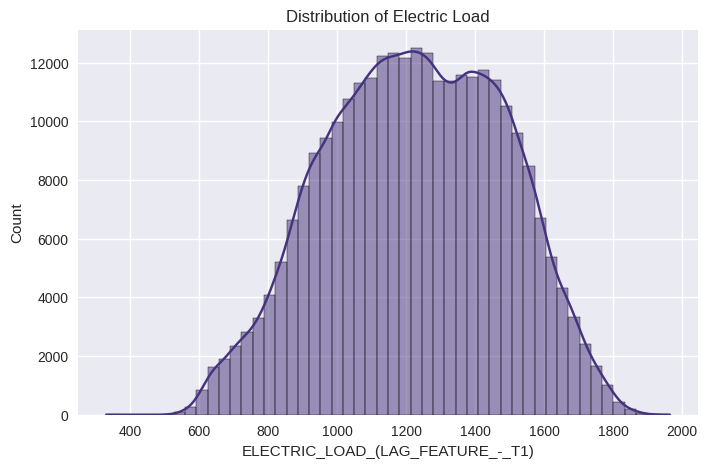

In [31]:
plt.figure(figsize=(8,5))
sns.histplot(df['ELECTRIC_LOAD_(LAG_FEATURE_-_T1)'], bins=50, kde=True)
plt.title("Distribution of Electric Load")
plt.show()

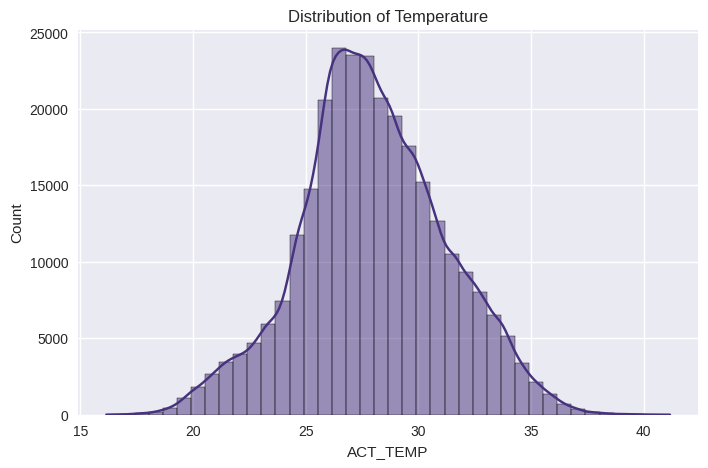

In [32]:
plt.figure(figsize=(8,5))
sns.histplot(df['ACT_TEMP'], bins=40, kde=True)
plt.title("Distribution of Temperature")
plt.show()

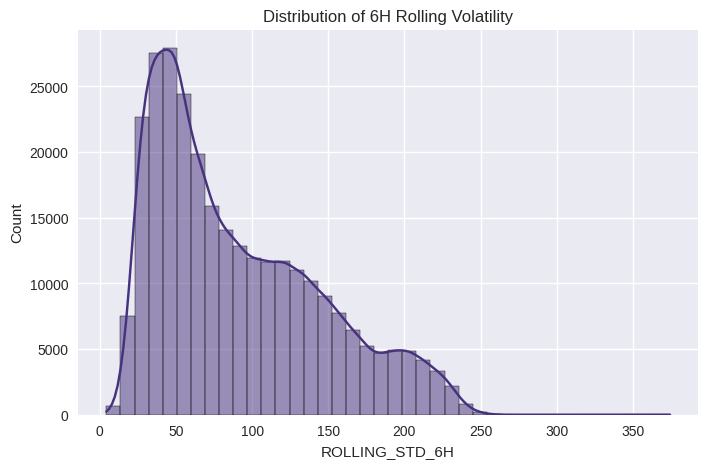

In [34]:
plt.figure(figsize=(8,5))
sns.histplot(df['ROLLING_STD_6H'], bins=40, kde=True)
plt.title("Distribution of 6H Rolling Volatility")
plt.show()

Load Over Time
Purpose:
Show seasonality + structural breaks.

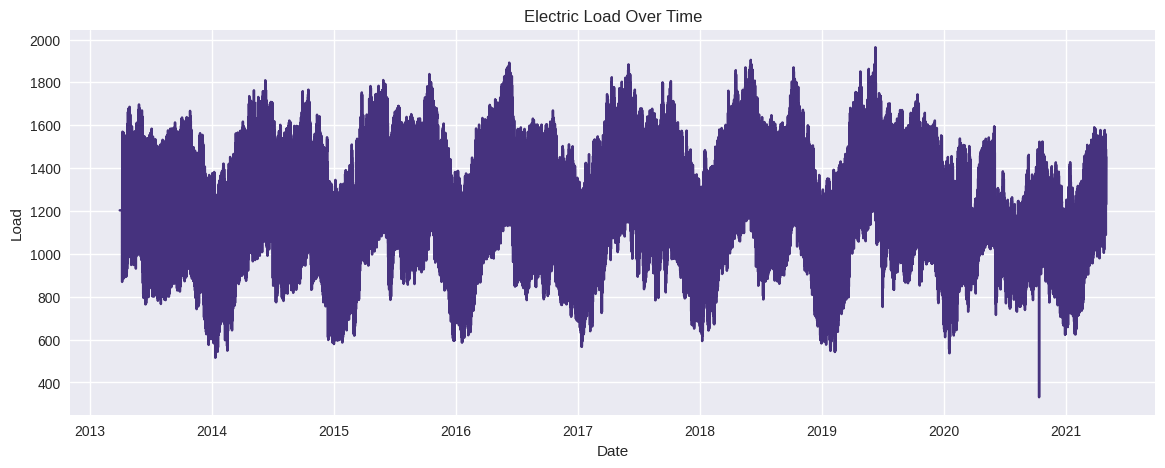

In [40]:
plt.figure(figsize=(14,5))
plt.plot(df['DATETIME_PARSED'], df['LOAD_T_1'])
plt.title("Electric Load Over Time")
plt.xlabel("Date")
plt.ylabel("Load")
plt.show()

Hourly Average Load Purpose:
Prove peak hours.

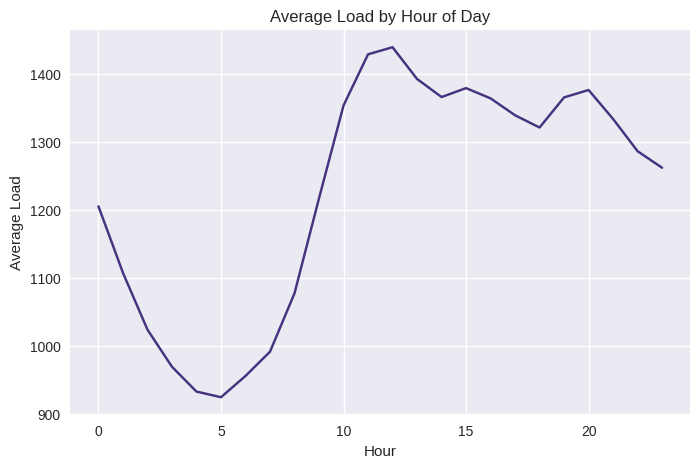

In [42]:
hourly_avg = df.groupby("HOUR")["LOAD_T_1"].mean()

plt.figure(figsize=(8,5))
plt.plot(hourly_avg.index, hourly_avg.values)
plt.title("Average Load by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Average Load")
plt.show()

Load vs Peak (Boxplot)

Purpose:
Show risk concentration.

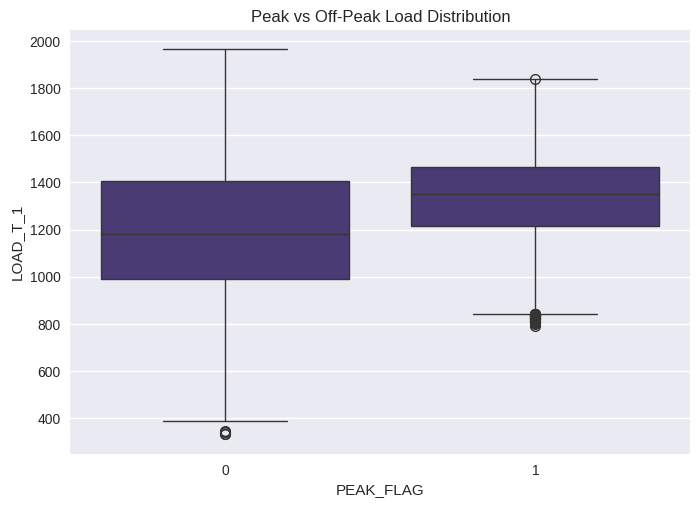

In [44]:
sns.boxplot(x="PEAK_FLAG", y="LOAD_T_1", data=df)
plt.title("Peak vs Off-Peak Load Distribution")
plt.show()

Lag Feature Strength (Very Important)

Use:
LOAD_T_96


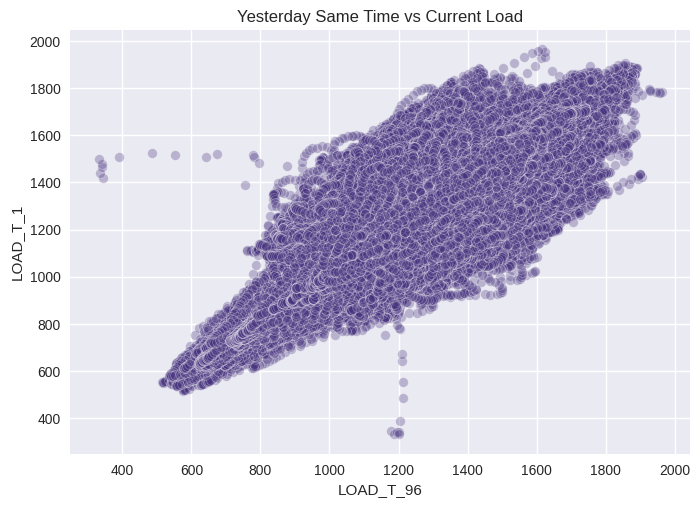

In [50]:
sns.scatterplot(x="LOAD_T_96", y="LOAD_T_1", data=df, alpha=0.3)
plt.title("Yesterday Same Time vs Current Load")
plt.show()

Rolling Volatility Over Time

Purpose:
Regime shift detection.

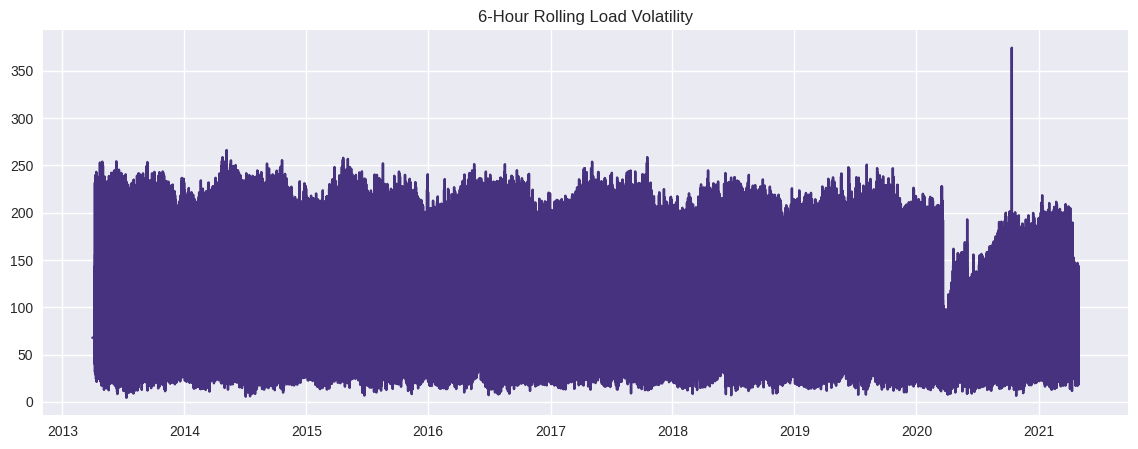

In [51]:
plt.figure(figsize=(14,5))
plt.plot(df['DATETIME_PARSED'], df['ROLLING_STD_6H'])
plt.title("6-Hour Rolling Load Volatility")
plt.show()

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Select numeric columns only
numeric_df = df.select_dtypes(include=np.number)

print(numeric_df.columns)

Index(['YEAR', 'MONTH', 'DAY', 'HOUR', 'MINUTE', 'SECOND', 'ACT_HEAT_INDEX',
       'ACT_HUMIDITY', 'ACT_RAIN', 'ACT_TEMP', 'COOL_FACTOR',
       'ELECTRIC_LOAD_(LAG_FEATURE_-_T1)', 'HOLIDAY_IND', 'IS_WEEKEND',
       'PEAK_FLAG', 'UNLOCK_1.0/MISSION_BEGIN_AGAIN',
       'UNLOCK_2.0/MISSION_BEGIN_AGAIN', 'UNLOCK_3.0', 'UNLOCK_4.0',
       'UNLOCK_5.0', 'UNLOCK_6.0', 'EXTREMELY_HEAVY_RAINFALL_(>100_MM)',
       'PARTIAL_WORK_FROM_HOME_(WFH)', 'LOCKDOWN', 'HOUR_SIN', 'HOUR_COS',
       'LOAD_T_1', 'LOAD_T_4', 'LOAD_T_96', 'LOAD_T_672', 'ROLLING_MEAN_1H',
       'ROLLING_MEAN_6H', 'ROLLING_STD_6H', 'DIFF_T_1', 'DIFF_1H', 'FESTIVAL',
       'GRID'],
      dtype='object')


Justify feature engineering,
Detect multicollinearity,
Remove useless features

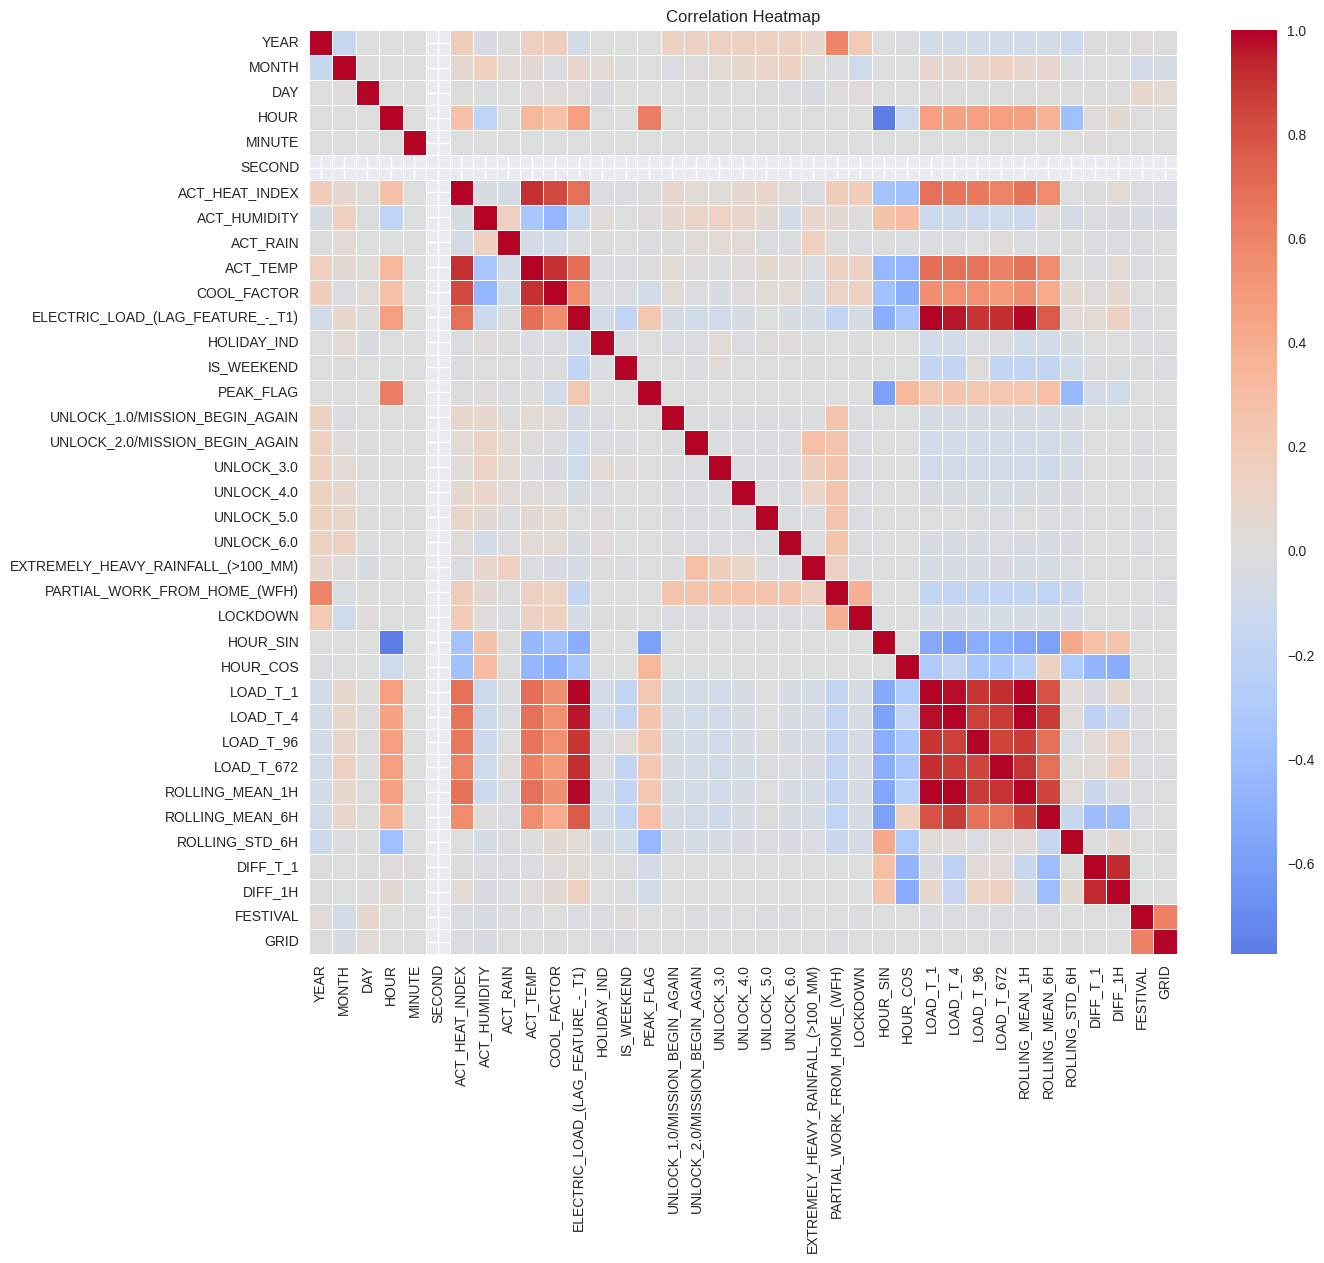

In [53]:
plt.figure(figsize=(14,12))
corr = numeric_df.corr()

sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

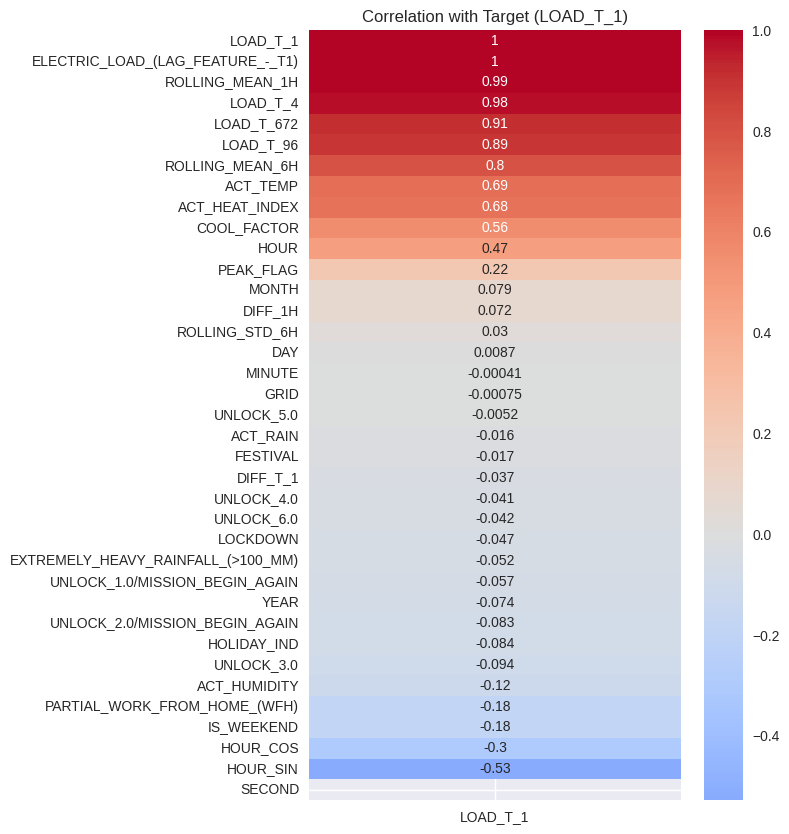

In [54]:
target_corr = corr["LOAD_T_1"].sort_values(ascending=False)

plt.figure(figsize=(6,10))
sns.heatmap(target_corr.to_frame(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation with Target (LOAD_T_1)")
plt.show()

features with |correlation| > 0.3

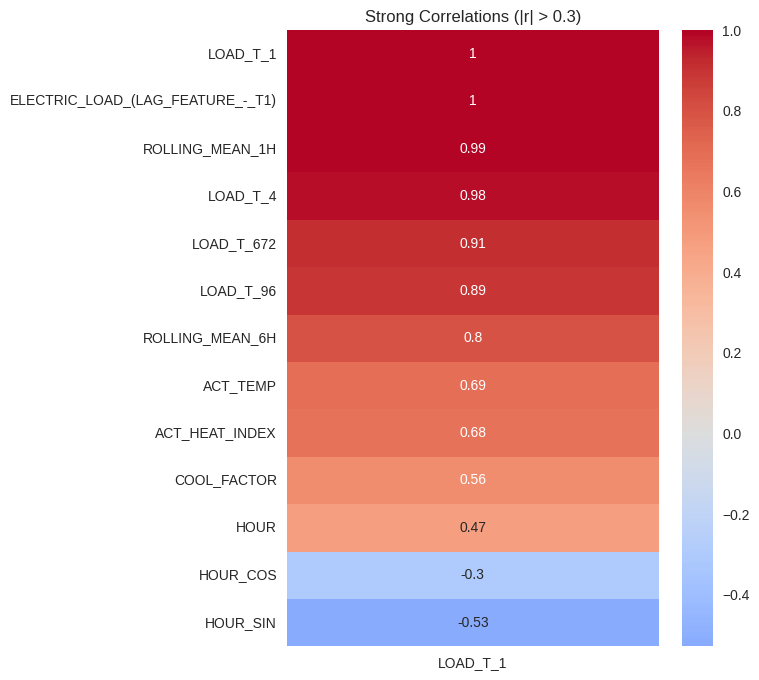

In [55]:
high_corr = target_corr[abs(target_corr) > 0.3]

plt.figure(figsize=(6,8))
sns.heatmap(high_corr.to_frame(), annot=True, cmap="coolwarm", center=0)
plt.title("Strong Correlations (|r| > 0.3)")
plt.show()